In [5]:
!mkdir -p ./data/cifar-10-batches-py
!wget -O ./data/cifar-10-python.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xzf ./data/cifar-10-python.tar.gz -C ./data/

--2026-06-12 07:27:26--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘./data/cifar-10-python.tar.gz’

./data/cifar-10-pyt 100%[===================>] 162.60M   239KB/s    in 6m 35s  

2026-06-12 07:34:01 (421 KB/s) - ‘./data/cifar-10-python.tar.gz’ saved [170498071/170498071]



In [6]:
!pip install torch torchvision matplotlib numpy -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import random
import copy
import matplotlib.pyplot as plt
from collections import deque

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cpu


In [7]:
from torch.utils.data import TensorDataset
import torch.nn.functional as F
from tensorflow.keras.datasets import cifar10
from torch.utils.data import TensorDataset
DATASET_NAME = "cifar10"

NUM_CLIENTS = 20
MAX_TRAIN_SAMPLES = 20000
MAX_TEST_SAMPLES = 5000
def load_dataset(dataset_name):
    dataset_name = dataset_name.lower()

    if dataset_name == "cifar10":
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()

        x_train = torch.tensor(x_train, dtype=torch.float32)
        x_test = torch.tensor(x_test, dtype=torch.float32)

        x_train = x_train.permute(0,3,1,2) / 255.0
        x_test = x_test.permute(0,3,1,2) / 255.0

        y_train = torch.tensor(y_train.squeeze(), dtype=torch.long)
        y_test = torch.tensor(y_test.squeeze(), dtype=torch.long)

        train_data = TensorDataset(x_train, y_train)
        test_data = TensorDataset(x_test, y_test)

        num_classes = 10
        input_type = "image_rgb"

    elif dataset_name == "emnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        train_data = datasets.EMNIST(
            root="./data",
            split="byclass",
            train=True,
            download=True,
            transform=transform
        )

        test_data = datasets.EMNIST(
            root="./data",
            split="byclass",
            train=False,
            download=True,
            transform=transform
        )

        num_classes = 62
        input_type = "image_gray"

    elif dataset_name == "imdb":
        from tensorflow.keras.datasets import imdb
        from tensorflow.keras.preprocessing.sequence import pad_sequences

        vocab_size = 10000
        max_len = 200

        (x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

        x_train = pad_sequences(x_train, maxlen=max_len, padding="post", truncating="post")
        x_test = pad_sequences(x_test, maxlen=max_len, padding="post", truncating="post")

        x_train = torch.tensor(x_train, dtype=torch.long)
        y_train = torch.tensor(y_train, dtype=torch.long)
        x_test = torch.tensor(x_test, dtype=torch.long)
        y_test = torch.tensor(y_test, dtype=torch.long)

        train_data = TensorDataset(x_train, y_train)
        test_data = TensorDataset(x_test, y_test)

        num_classes = 2
        input_type = "text"

    else:
        raise ValueError("Choose: cifar10, emnist, imdb")

    if MAX_TRAIN_SAMPLES is not None:
        train_data = Subset(train_data, list(range(min(MAX_TRAIN_SAMPLES, len(train_data)))))

    if MAX_TEST_SAMPLES is not None:
        test_data = Subset(test_data, list(range(min(MAX_TEST_SAMPLES, len(test_data)))))

    test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

    return train_data, test_data, test_loader, num_classes, input_type

In [8]:


def get_labels(dataset):
    if isinstance(dataset, Subset):
        base_dataset = dataset.dataset
        indices = dataset.indices
        base_labels = get_labels(base_dataset)
        return np.array(base_labels)[indices]

    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)

    if hasattr(dataset, "labels"):
        return np.array(dataset.labels)

    if isinstance(dataset, TensorDataset):
        return dataset.tensors[1].numpy()

    raise ValueError("Could not extract labels from dataset.")

def create_iid_clients(dataset, num_clients=20):
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    client_size = len(indices) // num_clients
    clients = []

    for i in range(num_clients):
        start = i * client_size
        end = (i + 1) * client_size
        client_indices = indices[start:end]
        clients.append(Subset(dataset, client_indices))

    return clients


def create_non_iid_clients(dataset, num_clients=20, shards_per_client=2):
    labels = get_labels(dataset)

    indices = list(range(len(dataset)))
    indices.sort(key=lambda i: labels[i])

    num_shards = num_clients * shards_per_client
    shard_size = len(dataset) // num_shards

    shards = []

    for i in range(num_shards):
        start = i * shard_size
        end = (i + 1) * shard_size
        shards.append(indices[start:end])

    random.shuffle(shards)

    clients = []

    for i in range(num_clients):
        client_indices = []

        for j in range(shards_per_client):
            shard_id = i * shards_per_client + j
            client_indices += shards[shard_id]

        clients.append(Subset(dataset, client_indices))

    return clients

In [9]:
DATASET_NAME = "emnist"

train_data, test_data, test_loader, NUM_CLASSES, INPUT_TYPE = load_dataset(DATASET_NAME)

clients = create_non_iid_clients(
    train_data,
    num_clients=NUM_CLIENTS,
    shards_per_client=2
)

print("Dataset:", DATASET_NAME)
print("Input type:", INPUT_TYPE)
print("Classes:", NUM_CLASSES)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))
print("Clients:", len(clients))
print("Samples per client:", len(clients[0]))

100%|██████████| 562M/562M [00:06<00:00, 88.0MB/s]


Dataset: emnist
Input type: image_gray
Classes: 62
Train samples: 20000
Test samples: 5000
Clients: 20
Samples per client: 1000


In [10]:
class EMNISTCNN(nn.Module):

    def __init__(self, num_classes=62):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [11]:
def get_model(dataset_name):

    dataset_name = dataset_name.lower()

    if dataset_name == "emnist":
        return EMNISTCNN(num_classes=62).to(device)

    raise ValueError("Model not implemented yet")
model = get_model(DATASET_NAME)

print(model)

EMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=62, bias=True)
  )
)


In [12]:
def get_weights(model):
    """
    Extract all model parameters
    """

    return copy.deepcopy(model.state_dict())


def set_weights(model, weights):
    """
    Load weights into model
    """

    model.load_state_dict(copy.deepcopy(weights))


def zeros_like_weights(weights):
    """
    Create zero-valued weight structure
    """

    return {
        k: torch.zeros_like(v)
        for k, v in weights.items()
    }


def scale_weights(weights, scale):
    """
    Multiply every parameter by scale
    """

    return {
        k: weights[k] * scale
        for k in weights
    }


def add_weights(w1, w2):
    """
    Add two models
    """

    return {
        k: w1[k] + w2[k]
        for k in w1
    }


def subtract_weights(w1, w2):
    """
    Difference between models
    """

    return {
        k: w1[k] - w2[k]
        for k in w1
    }

In [13]:
model = get_model(DATASET_NAME)

weights = get_weights(model)

print(type(weights))
print(len(weights))

<class 'collections.OrderedDict'>
8


In [14]:
client_battery = np.random.uniform(0.4, 1.0, NUM_CLIENTS)
client_latency = np.random.uniform(0.1, 1.0, NUM_CLIENTS)
client_participation = np.zeros(NUM_CLIENTS)

client_accuracy = np.zeros(NUM_CLIENTS)
client_loss = np.ones(NUM_CLIENTS)
client_prev_loss = np.ones(NUM_CLIENTS)
client_loss_drop = np.zeros(NUM_CLIENTS)
client_drift = np.zeros(NUM_CLIENTS)
client_update_norm = np.zeros(NUM_CLIENTS)

print("Battery:", client_battery[:5])
print("Latency:", client_latency[:5])
print("Participation:", client_participation[:5])

Battery: [0.49359671 0.43485017 0.91970569 0.76066901 0.82484355]
Latency: [0.80665837 0.2797064  0.56281099 0.63317311 0.14180537]
Participation: [0. 0. 0. 0. 0.]


In [15]:
def compute_drift(global_weights, client_weights):
    """
    Drift = distance between client model and global model
    """

    total = 0.0

    for key in global_weights:
        diff = client_weights[key] - global_weights[key]
        total += torch.sum(diff ** 2).item()

    return total ** 0.5


def normalize_array(arr):
    """
    Converts values to 0-1 range
    """

    arr = np.array(arr, dtype=np.float32)

    if arr.max() - arr.min() < 1e-8:
        return np.zeros_like(arr)

    return (arr - arr.min()) / (arr.max() - arr.min())


def compute_client_priority():
    acc_n = normalize_array(client_accuracy)
    loss_drop_n = normalize_array(client_loss_drop)
    drift_n = normalize_array(client_drift)
    battery_n = normalize_array(client_battery)
    latency_n = normalize_array(client_latency)
    participation_n = normalize_array(client_participation)

    fairness = 1.0 / (client_participation + 1.0)
    fairness_n = normalize_array(fairness)

    # noisy-client penalty using drift and update norm
    drift_threshold = np.mean(client_drift) + np.std(client_drift)
    update_threshold = np.mean(client_update_norm) + np.std(client_update_norm)

    noisy_penalty = np.ones(NUM_CLIENTS)

    for i in range(NUM_CLIENTS):
        if client_drift[i] > drift_threshold or client_update_norm[i] > update_threshold:
            noisy_penalty[i] = 0.5

    priority = (
        0.20 * acc_n
        + 0.25 * loss_drop_n
        + 0.15 * drift_n
        + 0.15 * battery_n
        + 0.15 * fairness_n
        - 0.05 * latency_n
        - 0.05 * participation_n
    )

    priority = priority * noisy_penalty

    return priority

In [16]:
def select_priority_clients(M):
    """
    Select top M clients based on priority score
    """

    priority_scores = compute_client_priority()

    selected_clients = np.argsort(priority_scores)[-M:]

    selected_clients = selected_clients.tolist()

    return selected_clients, priority_scores

In [17]:
selected_clients, priority_scores = select_priority_clients(M=5)

print("Selected clients:", selected_clients)
print("Priority scores:", priority_scores)

Selected clients: [15, 2, 4, 7, 6]
Priority scores: [-0.0189153  -0.00294932  0.10784563  0.06176652  0.10798027 -0.03077371
  0.14269066  0.12663287 -0.01880229 -0.02452289 -0.01583111  0.03031106
  0.07626488  0.0301066   0.0209776   0.08871846 -0.00595198  0.0429084
  0.00765868  0.05676179]


In [18]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0
    loss_sum = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss_sum += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    accuracy = correct / total
    avg_loss = loss_sum / len(test_loader)

    return avg_loss, accuracy

In [19]:
def local_train(
    global_weights,
    client_dataset,
    epochs=1,
    batch_size=32,
    lr=0.01
):

    model = get_model(DATASET_NAME)

    set_weights(model, global_weights)

    loader = DataLoader(
        client_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    model.train()

    total_loss = 0.0

    for _ in range(epochs):

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    return (
        get_weights(model),
        avg_loss
    )

In [20]:
global_model = get_model(DATASET_NAME)

global_weights = get_weights(global_model)

client_weights, client_loss_value = local_train(
    global_weights,
    clients[0],
    epochs=1,
    batch_size=32,
    lr=0.01
)

print("Client Loss:", client_loss_value)

Client Loss: 1.1668830174021423


In [21]:
def compute_update_norm(global_weights, client_weights):

    total = 0.0

    for key in global_weights:

        diff = client_weights[key] - global_weights[key]

        total += torch.sum(diff ** 2).item()

    return total ** 0.5

In [22]:
def update_client_metrics(
    client_id,
    local_loss,
    drift,
    update_norm
):

    client_prev_loss[client_id] = client_loss[client_id]

    client_loss[client_id] = local_loss

    client_loss_drop[client_id] = (
        client_prev_loss[client_id]
        - client_loss[client_id]
    )

    client_drift[client_id] = drift

    client_update_norm[client_id] = update_norm

    client_participation[client_id] += 1

In [23]:
drift = compute_drift(
    global_weights,
    client_weights
)

update_norm = compute_update_norm(
    global_weights,
    client_weights
)

update_client_metrics(
    client_id=0,
    local_loss=client_loss_value,
    drift=drift,
    update_norm=update_norm
)

print("Loss:", client_loss[0])
print("Loss Drop:", client_loss_drop[0])
print("Drift:", client_drift[0])
print("Update Norm:", client_update_norm[0])

Loss: 1.1668830174021423
Loss Drop: -0.1668830174021423
Drift: 0.7487204922225926
Update Norm: 0.7487204922225926


In [24]:
def weighted_average(client_weights_list, client_sizes):
    total_size = sum(client_sizes)

    avg_weights = zeros_like_weights(client_weights_list[0])

    for weights, size in zip(client_weights_list, client_sizes):
        weight_factor = size / total_size

        for key in avg_weights:
            avg_weights[key] += weights[key] * weight_factor

    return avg_weights

In [25]:
def run_one_round_fedavg(
    global_model,
    selected_clients,
    E=1,
    B=32,
    lr=0.01
):
    global_weights = get_weights(global_model)

    client_weights_list = []
    client_sizes = []

    for client_id in selected_clients:

        client_weights, local_loss = local_train(
            global_weights,
            clients[client_id],
            epochs=E,
            batch_size=B,
            lr=lr
        )

        drift = compute_drift(global_weights, client_weights)
        update_norm = compute_update_norm(global_weights, client_weights)

        update_client_metrics(
            client_id=client_id,
            local_loss=local_loss,
            drift=drift,
            update_norm=update_norm
        )

        client_weights_list.append(client_weights)
        client_sizes.append(len(clients[client_id]))

    new_global_weights = weighted_average(
        client_weights_list,
        client_sizes
    )

    set_weights(global_model, new_global_weights)

    global_loss, global_acc = evaluate(global_model, test_loader)

    return global_loss, global_acc

In [26]:
def train_fedavg(
    rounds=10,
    clients_per_round=5,
    E=1,
    B=32,
    lr=0.01
):

    global_model = get_model(DATASET_NAME)

    history_acc = []
    history_loss = []

    for rnd in range(rounds):

        selected_clients, _ = select_priority_clients(
            M=clients_per_round
        )

        loss, acc = run_one_round_fedavg(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr
        )

        history_loss.append(loss)
        history_acc.append(acc)

        print(
            f"Round {rnd+1}/{rounds} | "
            f"Loss={loss:.4f} | "
            f"Acc={acc:.4f}"
        )

    return global_model, history_loss, history_acc

In [27]:
fedavg_model, fedavg_loss, fedavg_acc = train_fedavg(
    rounds=5,
    clients_per_round=5,
    E=1,
    B=32,
    lr=0.01
)

Round 1/5 | Loss=4.1205 | Acc=0.0668
Round 2/5 | Loss=3.7726 | Acc=0.0688
Round 3/5 | Loss=3.7630 | Acc=0.0950
Round 4/5 | Loss=3.8518 | Acc=0.1162
Round 5/5 | Loss=3.1689 | Acc=0.3204


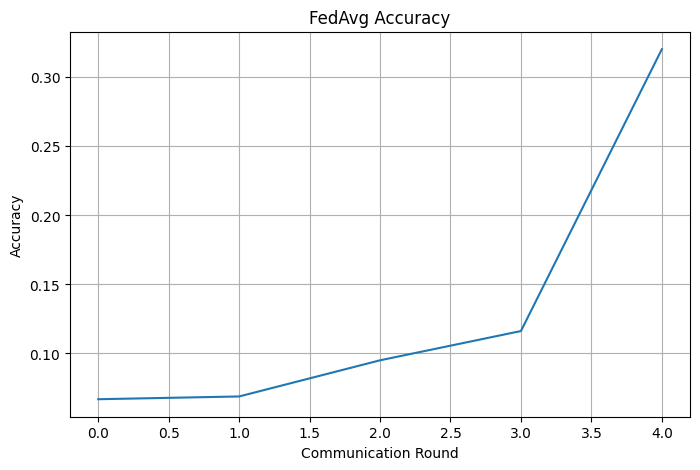

In [28]:
plt.figure(figsize=(8,5))

plt.plot(fedavg_acc)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("FedAvg Accuracy")

plt.grid(True)

plt.show()

In [29]:
def local_train_fedprox(
    global_weights,
    client_dataset,
    epochs=1,
    batch_size=32,
    lr=0.01,
    mu=0.01
):
    model = get_model(DATASET_NAME)
    set_weights(model, global_weights)

    global_reference = get_model(DATASET_NAME)
    set_weights(global_reference, global_weights)

    loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()

    total_loss = 0.0

    for _ in range(epochs):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            prox_term = 0.0

            for local_param, global_param in zip(
                model.parameters(),
                global_reference.parameters()
            ):
                prox_term += torch.sum((local_param - global_param) ** 2)

            loss = loss + (mu / 2) * prox_term

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    return get_weights(model), avg_loss

In [30]:
def run_one_round_fedprox(
    global_model,
    selected_clients,
    E=1,
    B=32,
    lr=0.01,
    mu=0.01
):
    global_weights = get_weights(global_model)

    client_weights_list = []
    client_sizes = []

    for client_id in selected_clients:
        client_weights, local_loss = local_train_fedprox(
            global_weights,
            clients[client_id],
            epochs=E,
            batch_size=B,
            lr=lr,
            mu=mu
        )

        drift = compute_drift(global_weights, client_weights)
        update_norm = compute_update_norm(global_weights, client_weights)

        update_client_metrics(
            client_id=client_id,
            local_loss=local_loss,
            drift=drift,
            update_norm=update_norm
        )

        client_weights_list.append(client_weights)
        client_sizes.append(len(clients[client_id]))

    new_global_weights = weighted_average(client_weights_list, client_sizes)
    set_weights(global_model, new_global_weights)

    global_loss, global_acc = evaluate(global_model, test_loader)

    return global_loss, global_acc

In [31]:
def train_fedprox(
    rounds=10,
    clients_per_round=5,
    E=1,
    B=32,
    lr=0.01,
    mu=0.01
):
    global_model = get_model(DATASET_NAME)

    history_acc = []
    history_loss = []

    for rnd in range(rounds):
        selected_clients, _ = select_priority_clients(M=clients_per_round)

        loss, acc = run_one_round_fedprox(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr,
            mu=mu
        )

        history_loss.append(loss)
        history_acc.append(acc)

        print(
            f"FedProx Round {rnd+1}/{rounds} | "
            f"Loss={loss:.4f} | Acc={acc:.4f}"
        )

    return global_model, history_loss, history_acc

In [32]:
fedprox_model, fedprox_loss, fedprox_acc = train_fedprox(
    rounds=5,
    clients_per_round=5,
    E=1,
    B=32,
    lr=0.01,
    mu=0.01
)

FedProx Round 1/5 | Loss=4.0666 | Acc=0.0436
FedProx Round 2/5 | Loss=3.7699 | Acc=0.0610
FedProx Round 3/5 | Loss=3.7959 | Acc=0.1652
FedProx Round 4/5 | Loss=3.8868 | Acc=0.2242
FedProx Round 5/5 | Loss=3.5202 | Acc=0.2128


In [33]:
# =========================
# 3. FedAvgM
# FedAvg + server momentum
# =========================

def train_fedavgm(rounds=10, clients_per_round=5, E=1, B=32, lr=0.01, server_lr=1.0, momentum=0.9):
    global_model = get_model(DATASET_NAME)
    global_weights = get_weights(global_model)

    velocity = zeros_like_weights(global_weights)

    history_loss, history_acc = [], []

    for rnd in range(rounds):
        selected_clients, _ = select_priority_clients(M=clients_per_round)

        client_weights_list = []
        client_sizes = []

        for client_id in selected_clients:
            client_weights, local_loss = local_train(
                global_weights,
                clients[client_id],
                epochs=E,
                batch_size=B,
                lr=lr
            )

            drift = compute_drift(global_weights, client_weights)
            update_norm = compute_update_norm(global_weights, client_weights)

            update_client_metrics(client_id, local_loss, drift, update_norm)

            client_weights_list.append(client_weights)
            client_sizes.append(len(clients[client_id]))

        avg_client_weights = weighted_average(client_weights_list, client_sizes)

        delta = subtract_weights(avg_client_weights, global_weights)

        for key in global_weights:
            velocity[key] = momentum * velocity[key] + delta[key]
            global_weights[key] = global_weights[key] + server_lr * velocity[key]

        set_weights(global_model, global_weights)

        loss, acc = evaluate(global_model, test_loader)

        history_loss.append(loss)
        history_acc.append(acc)

        print(f"FedAvgM Round {rnd+1}/{rounds} | Loss={loss:.4f} | Acc={acc:.4f}")

    return global_model, history_loss, history_acc

In [34]:
# =========================
# 4. FedNova
# Normalizes client updates by local steps
# =========================

def local_train_fednova(global_weights, client_dataset, epochs=1, batch_size=32, lr=0.01):
    model = get_model(DATASET_NAME)
    set_weights(model, global_weights)

    loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0.0
    steps = 0

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            steps += 1

    client_weights = get_weights(model)

    update = subtract_weights(global_weights, client_weights)

    normalized_update = scale_weights(update, 1 / max(steps, 1))

    avg_loss = total_loss / max(steps, 1)

    return normalized_update, steps, client_weights, avg_loss


def train_fednova(rounds=10, clients_per_round=5, E=1, B=32, lr=0.01):
    global_model = get_model(DATASET_NAME)
    global_weights = get_weights(global_model)

    history_loss, history_acc = [], []

    for rnd in range(rounds):
        selected_clients, _ = select_priority_clients(M=clients_per_round)

        updates = []
        client_sizes = []
        taus = []

        for client_id in selected_clients:
            normalized_update, tau, client_weights, local_loss = local_train_fednova(
                global_weights,
                clients[client_id],
                epochs=E,
                batch_size=B,
                lr=lr
            )

            drift = compute_drift(global_weights, client_weights)
            update_norm = compute_update_norm(global_weights, client_weights)

            update_client_metrics(client_id, local_loss, drift, update_norm)

            updates.append(normalized_update)
            client_sizes.append(len(clients[client_id]))
            taus.append(tau)

        total_size = sum(client_sizes)
        avg_update = zeros_like_weights(global_weights)
        avg_tau = 0.0

        for update, size, tau in zip(updates, client_sizes, taus):
            factor = size / total_size
            avg_tau += factor * tau

            for key in avg_update:
                avg_update[key] += factor * update[key]

        for key in global_weights:
            global_weights[key] = global_weights[key] - avg_tau * avg_update[key]

        set_weights(global_model, global_weights)

        loss, acc = evaluate(global_model, test_loader)

        history_loss.append(loss)
        history_acc.append(acc)

        print(f"FedNova Round {rnd+1}/{rounds} | Loss={loss:.4f} | Acc={acc:.4f}")

    return global_model, history_loss, history_acc

In [35]:
# =========================
# 5. SCAFFOLD
# Corrects client drift using c_global and c_client
# =========================

def local_train_scaffold(
    global_weights,
    client_dataset,
    c_global,
    c_client,
    epochs=1,
    batch_size=32,
    lr=0.01
):
    model = get_model(DATASET_NAME)
    set_weights(model, global_weights)

    initial_weights = copy.deepcopy(global_weights)

    loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0.0
    steps = 0

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            model.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()

            with torch.no_grad():
                for name, param in model.named_parameters():
                    param -= lr * (param.grad + c_global[name] - c_client[name])

            total_loss += loss.item()
            steps += 1

    new_weights = get_weights(model)

    new_c_client = {}

    for key in c_client:
        new_c_client[key] = (
            c_client[key]
            - c_global[key]
            + (initial_weights[key] - new_weights[key]) / (steps * lr)
        )

    delta_y = subtract_weights(new_weights, initial_weights)
    delta_c = subtract_weights(new_c_client, c_client)

    avg_loss = total_loss / max(steps, 1)

    return new_weights, new_c_client, delta_y, delta_c, avg_loss


def train_scaffold(rounds=10, clients_per_round=5, E=1, B=32, lr=0.01):
    global_model = get_model(DATASET_NAME)
    global_weights = get_weights(global_model)

    c_global = zeros_like_weights(global_weights)
    c_clients = [
        zeros_like_weights(global_weights)
        for _ in range(NUM_CLIENTS)
    ]

    history_loss, history_acc = [], []

    for rnd in range(rounds):
        selected_clients, _ = select_priority_clients(M=clients_per_round)

        delta_ys = []
        delta_cs = []

        for client_id in selected_clients:
            client_weights, new_c_client, delta_y, delta_c, local_loss = local_train_scaffold(
                global_weights,
                clients[client_id],
                c_global,
                c_clients[client_id],
                epochs=E,
                batch_size=B,
                lr=lr
            )

            c_clients[client_id] = new_c_client

            drift = compute_drift(global_weights, client_weights)
            update_norm = compute_update_norm(global_weights, client_weights)

            update_client_metrics(client_id, local_loss, drift, update_norm)

            delta_ys.append(delta_y)
            delta_cs.append(delta_c)

        avg_delta_y = weighted_average(delta_ys, [1] * len(delta_ys))
        avg_delta_c = weighted_average(delta_cs, [1] * len(delta_cs))

        for key in global_weights:
            global_weights[key] = global_weights[key] + avg_delta_y[key]
            c_global[key] = c_global[key] + (len(selected_clients) / NUM_CLIENTS) * avg_delta_c[key]

        set_weights(global_model, global_weights)

        loss, acc = evaluate(global_model, test_loader)

        history_loss.append(loss)
        history_acc.append(acc)

        print(f"SCAFFOLD Round {rnd+1}/{rounds} | Loss={loss:.4f} | Acc={acc:.4f}")

    return global_model, history_loss, history_acc

In [36]:
ROUNDS = 5
CLIENTS_PER_ROUND = 5
E = 1
B = 32
LR = 0.01

fedavg_model, fedavg_loss, fedavg_acc = train_fedavg(
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    E=E,
    B=B,
    lr=LR
)

fedprox_model, fedprox_loss, fedprox_acc = train_fedprox(
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    E=E,
    B=B,
    lr=LR,
    mu=0.01
)

fedavgm_model, fedavgm_loss, fedavgm_acc = train_fedavgm(
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    E=E,
    B=B,
    lr=LR,
    server_lr=1.0,
    momentum=0.9
)

fednova_model, fednova_loss, fednova_acc = train_fednova(
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    E=E,
    B=B,
    lr=LR
)

scaffold_model, scaffold_loss, scaffold_acc = train_scaffold(
    rounds=ROUNDS,
    clients_per_round=CLIENTS_PER_ROUND,
    E=E,
    B=B,
    lr=LR
)

Round 1/5 | Loss=4.1396 | Acc=0.1118
Round 2/5 | Loss=3.8868 | Acc=0.0734
Round 3/5 | Loss=3.8795 | Acc=0.1320
Round 4/5 | Loss=3.9733 | Acc=0.1526
Round 5/5 | Loss=3.7104 | Acc=0.1986
FedProx Round 1/5 | Loss=4.3986 | Acc=0.0834
FedProx Round 2/5 | Loss=3.9567 | Acc=0.0852
FedProx Round 3/5 | Loss=3.8994 | Acc=0.1354
FedProx Round 4/5 | Loss=3.9170 | Acc=0.1192
FedProx Round 5/5 | Loss=3.5756 | Acc=0.1826
FedAvgM Round 1/5 | Loss=3.9399 | Acc=0.0340
FedAvgM Round 2/5 | Loss=4.9567 | Acc=0.1700
FedAvgM Round 3/5 | Loss=6.7624 | Acc=0.1014
FedAvgM Round 4/5 | Loss=4.9439 | Acc=0.1946
FedAvgM Round 5/5 | Loss=3.5409 | Acc=0.2482
FedNova Round 1/5 | Loss=4.0787 | Acc=0.0456
FedNova Round 2/5 | Loss=3.9469 | Acc=0.1348
FedNova Round 3/5 | Loss=3.9525 | Acc=0.1514
FedNova Round 4/5 | Loss=3.7541 | Acc=0.1728
FedNova Round 5/5 | Loss=3.9481 | Acc=0.0964
SCAFFOLD Round 1/5 | Loss=4.2312 | Acc=0.0526
SCAFFOLD Round 2/5 | Loss=4.1604 | Acc=0.0726
SCAFFOLD Round 3/5 | Loss=3.7633 | Acc=0.0524
SC

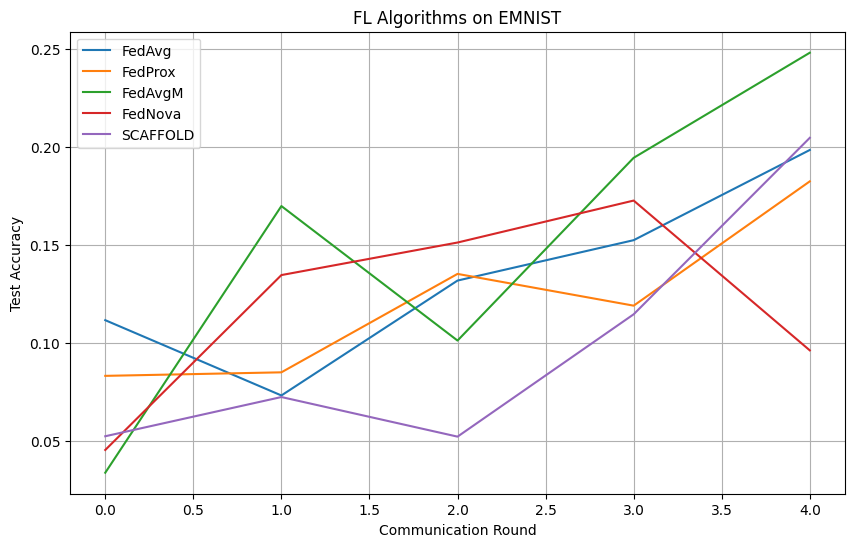

In [37]:
plt.figure(figsize=(10,6))

plt.plot(fedavg_acc, label="FedAvg")
plt.plot(fedprox_acc, label="FedProx")
plt.plot(fedavgm_acc, label="FedAvgM")
plt.plot(fednova_acc, label="FedNova")
plt.plot(scaffold_acc, label="SCAFFOLD")

plt.xlabel("Communication Round")
plt.ylabel("Test Accuracy")
plt.title(f"FL Algorithms on {DATASET_NAME.upper()}")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
ALGORITHMS = {
    0: "FedAvg",
    1: "FedProx",
    2: "FedNova",
    3: "SCAFFOLD",
    4: "FedAvgM"
}

In [53]:
ACTION_CONFIGS = []

for algo_id in range(5):
    for local_E in [1,3]:
        for clients_m in [5,10]:
            ACTION_CONFIGS.append({
                "algorithm_id": algo_id,
                "algorithm_name": ALGORITHMS[algo_id],
                "E": local_E,
                "clients_per_round": clients_m
            })

ACTION_SIZE = len(ACTION_CONFIGS)

print("Total actions:", ACTION_SIZE)

Total actions: 20


In [39]:
def run_algorithm_one_round(
    algorithm_id,
    global_model,
    selected_clients,
    scaffold_state=None,
    fedavgm_state=None,
    E=1,
    B=32,
    lr=0.01
):
    algo_name = ALGORITHMS[algorithm_id]

    if algo_name == "FedAvg":
        loss, acc = run_one_round_fedavg(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr
        )

    elif algo_name == "FedProx":
        loss, acc = run_one_round_fedprox(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr,
            mu=0.01
        )

    else:
        raise NotImplementedError(
            f"{algo_name} one-round wrapper will be added next."
        )

    return loss, acc, scaffold_state, fedavgm_state

In [40]:
def init_algorithm_states(global_model):
    global_weights = get_weights(global_model)

    scaffold_state = {
        "c_global": zeros_like_weights(global_weights),
        "c_clients": [
            zeros_like_weights(global_weights)
            for _ in range(NUM_CLIENTS)
        ]
    }

    fedavgm_state = {
        "velocity": zeros_like_weights(global_weights)
    }

    return scaffold_state, fedavgm_state

In [41]:
def run_one_round_fedavgm_wrapper(
    global_model,
    selected_clients,
    fedavgm_state,
    E=1,
    B=32,
    lr=0.01,
    server_lr=1.0,
    momentum=0.9
):
    global_weights = get_weights(global_model)
    velocity = fedavgm_state["velocity"]

    client_weights_list = []
    client_sizes = []

    for client_id in selected_clients:
        client_weights, local_loss = local_train(
            global_weights,
            clients[client_id],
            epochs=E,
            batch_size=B,
            lr=lr
        )

        drift = compute_drift(global_weights, client_weights)
        update_norm = compute_update_norm(global_weights, client_weights)

        update_client_metrics(client_id, local_loss, drift, update_norm)

        client_weights_list.append(client_weights)
        client_sizes.append(len(clients[client_id]))

    avg_client_weights = weighted_average(client_weights_list, client_sizes)
    delta = subtract_weights(avg_client_weights, global_weights)

    for key in global_weights:
        velocity[key] = momentum * velocity[key] + delta[key]
        global_weights[key] = global_weights[key] + server_lr * velocity[key]

    fedavgm_state["velocity"] = velocity

    set_weights(global_model, global_weights)

    return evaluate(global_model, test_loader), fedavgm_state

In [42]:
def run_one_round_fednova_wrapper(
    global_model,
    selected_clients,
    E=1,
    B=32,
    lr=0.01
):
    global_weights = get_weights(global_model)

    updates = []
    client_sizes = []
    taus = []

    for client_id in selected_clients:
        normalized_update, tau, client_weights, local_loss = local_train_fednova(
            global_weights,
            clients[client_id],
            epochs=E,
            batch_size=B,
            lr=lr
        )

        drift = compute_drift(global_weights, client_weights)
        update_norm = compute_update_norm(global_weights, client_weights)

        update_client_metrics(client_id, local_loss, drift, update_norm)

        updates.append(normalized_update)
        client_sizes.append(len(clients[client_id]))
        taus.append(tau)

    total_size = sum(client_sizes)
    avg_update = zeros_like_weights(global_weights)
    avg_tau = 0.0

    for update, size, tau in zip(updates, client_sizes, taus):
        factor = size / total_size
        avg_tau += factor * tau

        for key in avg_update:
            avg_update[key] += factor * update[key]

    for key in global_weights:
        global_weights[key] = global_weights[key] - avg_tau * avg_update[key]

    set_weights(global_model, global_weights)

    return evaluate(global_model, test_loader)

In [43]:
def run_one_round_scaffold_wrapper(
    global_model,
    selected_clients,
    scaffold_state,
    E=1,
    B=32,
    lr=0.01
):
    global_weights = get_weights(global_model)

    c_global = scaffold_state["c_global"]
    c_clients = scaffold_state["c_clients"]

    delta_ys = []
    delta_cs = []

    for client_id in selected_clients:
        client_weights, new_c_client, delta_y, delta_c, local_loss = local_train_scaffold(
            global_weights,
            clients[client_id],
            c_global,
            c_clients[client_id],
            epochs=E,
            batch_size=B,
            lr=lr
        )

        c_clients[client_id] = new_c_client

        drift = compute_drift(global_weights, client_weights)
        update_norm = compute_update_norm(global_weights, client_weights)

        update_client_metrics(client_id, local_loss, drift, update_norm)

        delta_ys.append(delta_y)
        delta_cs.append(delta_c)

    avg_delta_y = weighted_average(delta_ys, [1] * len(delta_ys))
    avg_delta_c = weighted_average(delta_cs, [1] * len(delta_cs))

    for key in global_weights:
        global_weights[key] = global_weights[key] + avg_delta_y[key]
        c_global[key] = c_global[key] + (len(selected_clients) / NUM_CLIENTS) * avg_delta_c[key]

    scaffold_state["c_global"] = c_global
    scaffold_state["c_clients"] = c_clients

    set_weights(global_model, global_weights)

    return evaluate(global_model, test_loader), scaffold_state

In [44]:
def run_algorithm_one_round(
    algorithm_id,
    global_model,
    selected_clients,
    scaffold_state=None,
    fedavgm_state=None,
    E=1,
    B=32,
    lr=0.01
):
    algo_name = ALGORITHMS[algorithm_id]

    if algo_name == "FedAvg":
        loss, acc = run_one_round_fedavg(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr
        )

    elif algo_name == "FedProx":
        loss, acc = run_one_round_fedprox(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr,
            mu=0.01
        )

    elif algo_name == "FedNova":
        loss, acc = run_one_round_fednova_wrapper(
            global_model,
            selected_clients,
            E=E,
            B=B,
            lr=lr
        )

    elif algo_name == "SCAFFOLD":
        (loss, acc), scaffold_state = run_one_round_scaffold_wrapper(
            global_model,
            selected_clients,
            scaffold_state,
            E=E,
            B=B,
            lr=lr
        )

    elif algo_name == "FedAvgM":
        (loss, acc), fedavgm_state = run_one_round_fedavgm_wrapper(
            global_model,
            selected_clients,
            fedavgm_state,
            E=E,
            B=B,
            lr=lr
        )

    else:
        raise ValueError("Invalid algorithm id")

    return loss, acc, scaffold_state, fedavgm_state

In [45]:
global_model = get_model(DATASET_NAME)
scaffold_state, fedavgm_state = init_algorithm_states(global_model)

selected_clients, _ = select_priority_clients(M=5)

for algorithm_id in range(5):
    loss, acc, scaffold_state, fedavgm_state = run_algorithm_one_round(
        algorithm_id,
        global_model,
        selected_clients,
        scaffold_state=scaffold_state,
        fedavgm_state=fedavgm_state,
        E=1,
        B=32,
        lr=0.01
    )

    print(ALGORITHMS[algorithm_id], "Loss:", loss, "Acc:", acc)

FedAvg Loss: 4.045456278324127 Acc: 0.128
FedProx Loss: 4.251916122436524 Acc: 0.0868
FedNova Loss: 4.282884979248047 Acc: 0.1588
SCAFFOLD Loss: 4.203738510608673 Acc: 0.2484
FedAvgM Loss: 4.253484404087066 Acc: 0.2854


In [46]:
previous_mean_drift = 0.0

def get_dqn_state(round_number, max_rounds, global_loss, global_acc):
    global previous_mean_drift

    current_mean_drift = np.mean(client_drift)
    drift_change = current_mean_drift - previous_mean_drift

    state = np.array([
        global_acc,
        global_loss,

        np.mean(client_loss),
        np.mean(client_loss_drop),

        current_mean_drift,
        np.var(client_drift),
        drift_change,

        np.mean(client_update_norm),
        np.var(client_update_norm),

        np.mean(client_battery),
        np.mean(client_latency),

        np.mean(client_participation) / max_rounds,

        round_number / max_rounds
    ], dtype=np.float32)

    previous_mean_drift = current_mean_drift

    return state

In [47]:
STATE_SIZE = 12
ACTION_SIZE = 5

In [48]:
dummy_state = get_dqn_state(
    round_number=1,
    max_rounds=30,
    global_loss=3.0,
    global_acc=0.05
)

print(dummy_state)
print("State shape:", dummy_state.shape)

[ 0.05        3.          1.3712074  -0.5332209   0.56202227  0.04408076
  0.56202227  0.56202227  0.04408076  0.6462413   0.5072662   0.335
  0.03333334]
State shape: (13,)


In [49]:
class DQN(nn.Module):
    def __init__(self, state_size=13, action_size=20):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)

In [54]:
STATE_SIZE = 13
ACTION_SIZE = len(ACTION_CONFIGS)

dummy_state_np = get_dqn_state(
    round_number=1,
    max_rounds=50,
    global_loss=3.0,
    global_acc=0.05
)

print(dummy_state_np)
print(dummy_state_np.shape)
dqn_test = DQN(
    state_size=STATE_SIZE,
    action_size=ACTION_SIZE
).to(device)

dummy_state = torch.tensor(
    dummy_state_np,
    dtype=torch.float32
).unsqueeze(0).to(device)

print(dummy_state.shape)

[ 0.05        3.          1.3712074  -0.5332209   0.56202227  0.04408076
  0.          0.56202227  0.04408076  0.6462413   0.5072662   0.201
  0.02      ]
(13,)
torch.Size([1, 13])


In [55]:


from collections import deque
import random

class ReplayBuffer:

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):
        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )

    def __len__(self):
        return len(self.buffer)

In [56]:
class DQNAgent:

    def __init__(
        self,
        state_size,
        action_size
    ):

        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.95

        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995

        self.batch_size = 64

        self.memory = ReplayBuffer()

        self.policy_net = DQN(
            state_size,
            action_size
        ).to(device)

        self.target_net = DQN(
            state_size,
            action_size
        ).to(device)

        self.target_net.load_state_dict(
            self.policy_net.state_dict()
        )

        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=0.001
        )

        self.loss_fn = nn.MSELoss()
    def select_action(
        self,
        state
    ):

        if np.random.rand() < self.epsilon:

            return random.randint(
                0,
                self.action_size - 1
            )

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            q_values = self.policy_net(
                state_tensor
            )

        return torch.argmax(
            q_values
        ).item()
    def remember(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.memory.push(
            state,
            action,
            reward,
            next_state,
            done
        )
    def train_step(self):

        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = \
            self.memory.sample(
                self.batch_size
            )

        states = torch.tensor(
            states,
            dtype=torch.float32
        ).to(device)

        actions = torch.tensor(
            actions,
            dtype=torch.long
        ).unsqueeze(1).to(device)

        rewards = torch.tensor(
            rewards,
            dtype=torch.float32
        ).unsqueeze(1).to(device)

        next_states = torch.tensor(
            next_states,
            dtype=torch.float32
        ).to(device)

        dones = torch.tensor(
            dones,
            dtype=torch.float32
        ).unsqueeze(1).to(device)

        current_q = self.policy_net(
            states
        ).gather(
            1,
            actions
        )

        next_q = self.target_net(
            next_states
        ).max(
            1,
            keepdim=True
        )[0]

        target_q = rewards + (
            1 - dones
        ) * self.gamma * next_q

        loss = self.loss_fn(
            current_q,
            target_q.detach()
        )

        self.optimizer.zero_grad()

        loss.backward()

        self.optimizer.step()

        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay
    def update_target(self):

        self.target_net.load_state_dict(
          self.policy_net.state_dict()
        )

In [ ]:
agent = DQNAgent(
    state_size=STATE_SIZE,
    action_size=ACTION_SIZE
)

print(agent.policy_net)

In [57]:
def compute_reward(
    prev_acc,
    new_acc,
    prev_loss,
    new_loss,
    selected_clients
):
    accuracy_gain = new_acc - prev_acc
    loss_reduction = prev_loss - new_loss

    mean_drift = np.mean([client_drift[cid] for cid in selected_clients])
    mean_latency = np.mean([client_latency[cid] for cid in selected_clients])
    mean_battery_used = np.mean([1.0 - client_battery[cid] for cid in selected_clients])

    reward = (
        2.0 * accuracy_gain
        + 0.5 * loss_reduction
        - 0.05 * mean_drift
        - 0.05 * mean_latency
        - 0.05 * mean_battery_used
    )

    return reward

In [58]:
def train_dqn_adaptive_fl(
    rounds=50,
    B=32,
    lr=0.01,
    target_update_every=5
):
    global previous_mean_drift
    previous_mean_drift = 0.0

    global_model = get_model(DATASET_NAME)

    scaffold_state, fedavgm_state = init_algorithm_states(global_model)

    agent = DQNAgent(
        state_size=STATE_SIZE,
        action_size=ACTION_SIZE
    )

    history_acc = []
    history_loss = []
    history_reward = []
    history_algorithm = []
    history_action_config = []

    prev_loss, prev_acc = evaluate(global_model, test_loader)

    state = get_dqn_state(
        round_number=0,
        max_rounds=rounds,
        global_loss=prev_loss,
        global_acc=prev_acc
    )

    for rnd in range(rounds):

        action = agent.select_action(state)

        cfg = ACTION_CONFIGS[action]

        selected_clients, priority_scores = select_priority_clients(
            M=cfg["clients_per_round"]
        )

        new_loss, new_acc, scaffold_state, fedavgm_state = run_algorithm_one_round(
            algorithm_id=cfg["algorithm_id"],
            global_model=global_model,
            selected_clients=selected_clients,
            scaffold_state=scaffold_state,
            fedavgm_state=fedavgm_state,
            E=cfg["E"],
            B=B,
            lr=lr
        )

        reward = compute_reward(
            prev_acc=prev_acc,
            new_acc=new_acc,
            prev_loss=prev_loss,
            new_loss=new_loss,
            selected_clients=selected_clients
        )

        next_state = get_dqn_state(
            round_number=rnd + 1,
            max_rounds=rounds,
            global_loss=new_loss,
            global_acc=new_acc
        )

        done = (rnd == rounds - 1)

        agent.remember(
            state,
            action,
            reward,
            next_state,
            done
        )

        agent.train_step()

        if rnd % target_update_every == 0:
            agent.update_target()

        history_acc.append(new_acc)
        history_loss.append(new_loss)
        history_reward.append(reward)
        history_algorithm.append(cfg["algorithm_name"])
        history_action_config.append(cfg)

        print(
            f"Round {rnd+1}/{rounds} | "
            f"Algo={cfg['algorithm_name']} | "
            f"E={cfg['E']} | "
            f"Clients={cfg['clients_per_round']} | "
            f"Loss={new_loss:.4f} | "
            f"Acc={new_acc:.4f} | "
            f"Reward={reward:.4f} | "
            f"Epsilon={agent.epsilon:.3f}"
        )

        state = next_state
        prev_loss = new_loss
        prev_acc = new_acc

    return {
        "model": global_model,
        "acc": history_acc,
        "loss": history_loss,
        "reward": history_reward,
        "algorithm": history_algorithm,
        "action_config": history_action_config,
        "agent": agent
    }

In [60]:
dqn_results_v2 = train_dqn_adaptive_fl(
    rounds=50,
    B=32,
    lr=0.01
)

Round 1/50 | Algo=FedNova | E=3 | Clients=10 | Loss=3.8245 | Acc=0.1030 | Reward=0.2438 | Epsilon=1.000
Round 2/50 | Algo=FedNova | E=3 | Clients=10 | Loss=3.5831 | Acc=0.1448 | Reward=0.1302 | Epsilon=1.000
Round 3/50 | Algo=FedAvgM | E=3 | Clients=10 | Loss=3.4508 | Acc=0.1602 | Reward=0.0244 | Epsilon=1.000
Round 4/50 | Algo=FedNova | E=1 | Clients=5 | Loss=3.6223 | Acc=0.1930 | Reward=-0.0817 | Epsilon=1.000
Round 5/50 | Algo=FedAvg | E=1 | Clients=10 | Loss=3.1034 | Acc=0.2542 | Reward=0.3146 | Epsilon=1.000
Round 6/50 | Algo=SCAFFOLD | E=3 | Clients=5 | Loss=2.8035 | Acc=0.3466 | Reward=0.2472 | Epsilon=1.000
Round 7/50 | Algo=FedAvgM | E=1 | Clients=10 | Loss=2.7707 | Acc=0.3160 | Reward=-0.1086 | Epsilon=1.000
Round 8/50 | Algo=FedAvg | E=3 | Clients=10 | Loss=2.5447 | Acc=0.3824 | Reward=0.1775 | Epsilon=1.000
Round 9/50 | Algo=SCAFFOLD | E=1 | Clients=5 | Loss=2.6381 | Acc=0.3846 | Reward=-0.0916 | Epsilon=1.000
Round 10/50 | Algo=FedAvg | E=3 | Clients=5 | Loss=2.7268 | Acc=

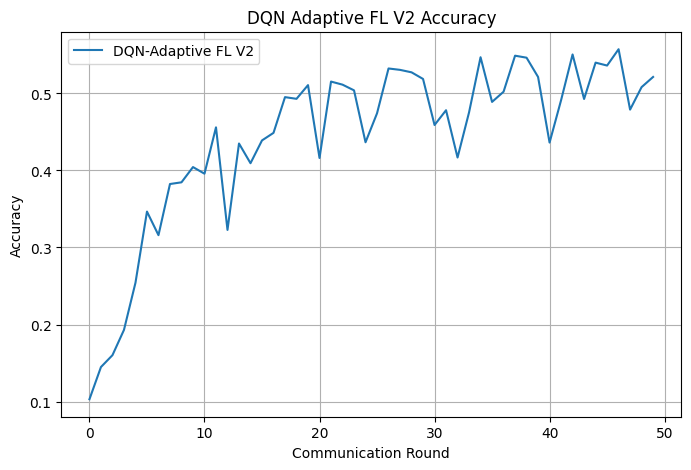

In [61]:
plt.figure(figsize=(8,5))
plt.plot(dqn_results_v2["acc"], label="DQN-Adaptive FL V2")
plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("DQN Adaptive FL V2 Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
!git clone https://github.com/Ramkrishna4816/rl-federated-learning.git

Cloning into 'rl-federated-learning'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [3]:
%cd rl-federated-learning

!git config --global user.email "s.ramkrishna888888@gmail.com"
!git config --global user.name "Ramkrishna4816"

!git add .
!git commit -m "Initial commit: RL-based Federated Learning controller"

!git branch -M main

/content/rl-federated-learning
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!git remote add origin https://github.com/Ramkrishna4816/rl-federated-learning.git

error: remote origin already exists.


In [5]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [6]:
%cd /content/rl-federated-learning
!git status

/content/rl-federated-learning
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [7]:
!git remote -v

origin	https://github.com/Ramkrishna4816/rl-federated-learning.git (fetch)
origin	https://github.com/Ramkrishna4816/rl-federated-learning.git (push)


In [8]:
!git log --oneline -5
!git ls-files

dd66499 (HEAD -> main, origin/main, origin/HEAD) Initial commit
README.md


In [9]:
!pwd
!find . -type f

/content/rl-federated-learning
./.git/info/exclude
./.git/COMMIT_EDITMSG
./.git/config
./.git/refs/heads/main
./.git/refs/remotes/origin/HEAD
./.git/index
./.git/packed-refs
./.git/description
./.git/hooks/commit-msg.sample
./.git/hooks/pre-commit.sample
./.git/hooks/pre-merge-commit.sample
./.git/hooks/pre-receive.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/pre-rebase.sample
./.git/hooks/post-update.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/update.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/applypatch-msg.sample
./.git/hooks/pre-push.sample
./.git/hooks/prepare-commit-msg.sample
./.git/HEAD
./.git/objects/pack/pack-dabb4de2730bb44b9ee18d7d05ff891a32e60db2.idx
./.git/objects/pack/pack-dabb4de2730bb44b9ee18d7d05ff891a32e60db2.pack
./.git/logs/refs/heads/main
./.git/logs/refs/remotes/origin/HEAD
./.git/logs/HEAD
./README.md


In [12]:
!find /content -name "*.ipynb"
!find /content -name "data.py"
!find /content -name "rl_agent.py"

In [13]:
%cd /content/rl-federated-learning

!ls -R

/content/rl-federated-learning
.:
README.md


In [14]:
%cd /content/rl-federated-learning

!mkdir -p notebooks src results report

!touch requirements.txt
!touch src/data.py
!touch src/federated_algorithms.py
!touch src/rl_agent.py
!touch src/train.py
!touch src/utils.py
!touch report/project_summary.md

!ls -R

/content/rl-federated-learning
.:
notebooks  README.md  report  requirements.txt	results  src

./notebooks:

./report:
project_summary.md

./results:

./src:
data.py  federated_algorithms.py  rl_agent.py  train.py  utils.py


In [15]:
!git add .
!git commit -m "Add project folder structure and source files"
!git push

[main e32c6cf] Add project folder structure and source files
 7 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 report/project_summary.md
 create mode 100644 requirements.txt
 create mode 100644 src/data.py
 create mode 100644 src/federated_algorithms.py
 create mode 100644 src/rl_agent.py
 create mode 100644 src/train.py
 create mode 100644 src/utils.py
fatal: could not read Username for 'https://github.com': No such device or address
